In [1]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import os
import re
import matplotlib.pyplot as plt
import re
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter  # for smoothing
from scipy.optimize import curve_fit
import geopandas as gpd


# Read dataset

In [164]:
df_coastsat = pd.read_csv('oahu0012_intersects_outliersremoved_COASTSAT.csv')
# df_coastsat['dates'] = pd.to_datetime(df_coastsat['dates'])
# df_coastsat['dates'] = df_coastsat['dates'].dt.tz_convert('Pacific/Honolulu')

# 1. Load the shapefile
shapefile_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\shapefiles\NS_transects.shp"
gdf = gpd.read_file(shapefile_path)

df_coastsat['dates'] = (
    pd.to_datetime(df_coastsat['dates'])                 # make sure it's datetime                     # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_coastsat['type'] = 'COASTSAT'
#df_coastsat = df_coastsat.drop(columns=['satname'])
df_coastsat = df_coastsat.set_index('dates')




df_planet = pd.read_csv('oahu0012_intersects_outliersremoved_PLANET.csv')
df_planet['dates'] = (
    pd.to_datetime(df_planet['dates'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_planet['type'] = 'PLANET'
df_planet = df_planet.rename(columns=lambda c: re.sub(r'^(?:oahu)+_?', 'oahu', c))
df_planet = df_planet.set_index('dates')




merged_planet_coast = pd.concat([df_coastsat, df_planet])  # or drop ignore_index to keep original index
merged_planet_coast = merged_planet_coast.sort_index()


# monthly -> add merge key
monthly_planet_coast  =  merged_planet_coast.resample('M').mean(numeric_only=True)

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\1979331248.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_planet_coast  =  merged_planet_coast.resample('M').mean(numeric_only=True)


# Compile ONI data, apply NOAA's 5 month consecutive winow for labeling ENSO phase

In [165]:
# Path to your uploaded ONI text file
file_path = r"oni.txt"

# Read and clean the fixed-width formatted data
df_oni = pd.read_csv(
    file_path,
    delim_whitespace=True,
    skiprows=1,          # skip the header line "SEAS  YR   TOTAL   ANOM"
    names=["SEAS", "YR", "TOTAL", "ANOM"],
    na_values=["", " "]
)

# Drop any completely empty rows
df_oni = df_oni.dropna(subset=["SEAS", "YR", "ANOM"])

# Create a datetime column — season midpoint (approx)
# We'll use the year and the season's middle month
month_map = {
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4, "AMJ": 5, "MJJ": 6,
    "JJA": 7, "JAS": 8, "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12
}
df_oni["month"] = df_oni["SEAS"].map(month_map)
df_oni["date"] = pd.to_datetime(df_oni["YR"].astype(int).astype(str) + "-" + df_oni["month"].astype(str) + "-15")

# Reorder columns for clarity
df_oni = df_oni[["date", "SEAS", "YR", "TOTAL", "ANOM"]]

# Display the first few rows
print(df_oni.head(15))

# ---- 3️⃣ Apply NOAA’s 5 overlapping 3-month rule ----
EL_NINO = 0.5
LA_NINA = -0.5
WINDOW = 5

oni_values = df_oni["ANOM"].values
phase = np.array(["Neutral"] * len(oni_values), dtype=object)

# --- El Niño detection ---
count = 0
for i in range(len(oni_values)):
    if oni_values[i] >= EL_NINO:
        count += 1
    else:
        count = 0
    if count >= WINDOW:
        phase[i - WINDOW + 1 : i + 1] = "El Niño"

# --- La Niña detection ---
count = 0
for i in range(len(oni_values)):
    if oni_values[i] <= LA_NINA:
        count += 1
    else:
        count = 0
    if count >= WINDOW:
        phase[i - WINDOW + 1 : i + 1] = "La Niña"

df_oni["ENSO_phase"] = phase


         date SEAS    YR  TOTAL  ANOM
0  1950-01-15  DJF  1950  24.72 -1.53
1  1950-02-15  JFM  1950  25.17 -1.34
2  1950-03-15  FMA  1950  25.75 -1.16
3  1950-04-15  MAM  1950  26.12 -1.18
4  1950-05-15  AMJ  1950  26.32 -1.07
5  1950-06-15  MJJ  1950  26.31 -0.85
6  1950-07-15  JJA  1950  26.21 -0.54
7  1950-08-15  JAS  1950  25.96 -0.42
8  1950-09-15  ASO  1950  25.76 -0.39
9  1950-10-15  SON  1950  25.63 -0.44
10 1950-11-15  OND  1950  25.48 -0.60
11 1950-12-15  NDJ  1950  25.34 -0.80
12 1951-01-15  DJF  1951  25.42 -0.82
13 1951-02-15  JFM  1951  25.96 -0.54
14 1951-03-15  FMA  1951  26.74 -0.17


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\5709585.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_oni = pd.read_csv(


In [4]:

# ---- Input ----
# df_oni must have: ['date','SEAS','YR','ANOM','ENSO_phase']
df = df_oni.copy()
df['ANOM'] = df['ANOM'].astype(float)

# Define relevant seasons (September–April)
target_seas = ["SON", "OND", "NDJ", "DJF", "JFM", "FMA"]

# Assign "wave season" = September of previous year to August of next year
df["season_year"] = df["YR"]
# OND–FMA belong to the *previous* September-starting season
df.loc[df["SEAS"].isin(["OND", "NDJ", "DJF", "JFM", "FMA"]), "season_year"] = df["YR"] - 1

# Filter to target seasons
df = df[df["SEAS"].isin(target_seas)]

# Group and extract peak anomaly info
records = []
for year, group in df.groupby("season_year"):
    if group.empty:
        continue
    group = group.sort_values("date")
    
    # Find record with maximum absolute anomaly
    idx = group["ANOM"].abs().idxmax()
    peak = group.loc[idx]
    
    start_dt = pd.to_datetime(f"{year}-09-01")
    end_dt = pd.to_datetime(f"{year+1}-08-31")
    
    records.append({
        "season": f"{year}-{year+1}",
        "start_dt": start_dt,
        "end_dt": end_dt,
        "peak_ANOM": round(peak["ANOM"], 2),
        "peak_SEAS": peak["SEAS"],
        "ENSO_phase_peak": peak["ENSO_phase"]
    })

df_peak_phase = pd.DataFrame(records)

# Ensure proper datatypes
df_peak_phase["start_dt"] = pd.to_datetime(df_peak_phase["start_dt"])
df_peak_phase["end_dt"] = pd.to_datetime(df_peak_phase["end_dt"])

df_peak_phase

,season,start_dt,end_dt,peak_ANOM,peak_SEAS,ENSO_phase_peak
0,1949-1950,1949-09-01,1950-08-31,-1.53,DJF,La Niña
1,1950-1951,1950-09-01,1951-08-31,1.04,OND,El Niño
2,1951-1952,1951-09-01,1952-08-31,1.15,SON,El Niño
3,1952-1953,1952-09-01,1953-08-31,0.84,OND,El Niño
4,1953-1954,1953-09-01,1954-08-31,0.84,SON,El Niño
...,...,...,...,...,...,...
71,2020-2021,2020-09-01,2021-08-31,-1.17,SON,La Niña
72,2021-2022,2021-09-01,2022-08-31,-0.99,FMA,La Niña
73,2022-2023,2022-09-01,2023-08-31,1.95,NDJ,El Niño
74,2023-2024,2023-09-01,2024-08-31,1.78,SON,El Niño


# Compile stats on beach widths

In [17]:
def generate_transect_list(start_transect, end_transect):
    """Generate a list of transect IDs from start to end, inclusive."""
    return [f"oahu0012_{i:04d}" for i in range(start_transect, end_transect + 1)]

def get_transect_stats(monthly_dataframe):
    refined_stats = {'baseline_std': [], 'baseline_average': [], 'transect': [], 'mean_monthly_max' : [], 'mean_monthly_min' : [], 'mean_max_std' : [], 'mean_min_std' : [], 'max_date' : [], 'min' : [], 'max' : []}

    for i in range(len(monthly_dataframe['data'])):
        maximum = monthly_dataframe['data'][i].mean_width.max()
        max_date = int(monthly_dataframe['data'][i]['month'][monthly_dataframe['data'][i]['mean_width'].idxmax()])
        max_std = monthly_dataframe['data'][i]['std_width'][monthly_dataframe['data'][i]['mean_width'].idxmax()]
        minimum = monthly_dataframe['data'][i].mean_width.min()
        max_outlier = monthly_dataframe['data'][i].max_width.max()
        min_outlier = monthly_dataframe['data'][i].min_width.min()
        min_std =  monthly_dataframe['data'][i]['std_width'][monthly_dataframe['data'][i]['mean_width'].idxmin()]
        transect =  monthly_dataframe['transect'][i]
        baseline_average = monthly_dataframe['baseline_average'][i]
        baseline_std = monthly_dataframe['baseline_std'][i]

        refined_stats['baseline_average'].append(baseline_average)
        refined_stats['baseline_std'].append(baseline_std)
        refined_stats['transect'].append(transect)
        refined_stats['mean_monthly_max'].append(maximum)
        refined_stats['mean_monthly_min'].append(minimum)
        refined_stats['mean_max_std'].append(max_std)
        refined_stats['mean_min_std'].append(min_std)
        refined_stats['max_date'].append(max_date)
        refined_stats['min'].append(min_outlier)
        refined_stats['max'].append(max_outlier)
        
    df_stats = pd.DataFrame(refined_stats)
    return df_stats

### Rolling 100m meter mean w/ ONI compiled info

In [18]:
df=  merged_planet_coast 
monthly_100m_stats_storage = {'transect': [] , 'data' : [], 'baseline_average' : [], 'baseline_std' : []}
last_transect_number = 246
lst = list(range(1, last_transect_number - 4))  # goes from 1 to 244


for i in lst:
    transects =  generate_transect_list(start_transect = i, end_transect = i+4)
    df['Average_from_transect'] = df[transects].mean(axis=1)
    averaged = df['Average_from_transect'].mean()
    std = df['Average_from_transect'].std()
    # Ensure datetime types
    df_oni['date'] = pd.to_datetime(df_oni['date'])
    df.index = df.index.tz_localize(None)
    df_oni['date'] = df_oni['date'].dt.tz_localize(None)
    
    df['year_month'] = df.index.to_period('M')
    df_oni['year_month'] = df_oni['date'].dt.to_period('M')

    
    # Merge ONI monthly values into df_planet
    merged_df = pd.merge(
        df.reset_index(),  # bring index as 'dates'
        df_oni[['year_month', 'ANOM', 'ENSO_phase', 'SEAS']],
        on='year_month',
        how='left'
    )

    # Assume your DataFrame is named merged_df and 'dates' is already datetime
    merged_df['dates'] = pd.to_datetime(merged_df['dates'])
    
    # Set the index for resampling
    merged_df = merged_df.set_index('dates')
    
    # Separate numeric and non-numeric columns
    num_cols = merged_df.select_dtypes(include=[np.number]).columns
    text_cols = merged_df.select_dtypes(exclude=[np.number]).columns
    
    # Define aggregation functions:
    agg_dict = {col: 'mean' for col in num_cols}
    # For text columns, keep the most frequent (mode) or the first non-null entry
    for col in text_cols:
        agg_dict[col] = lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else np.nan
    
    # --- Resample monthly and apply ---
    resampled_df = merged_df.resample('M').agg(agg_dict).reset_index()

    # --- Step 1. Resample to monthly means ---
    # 1‑line change
    # Resample to monthly means using the 'dates' column

    # Add a 'month' column
    monthly_df_ONI_compiled = resampled_df.copy()
    monthly_df_ONI_compiled.index.name = 'dates'
    monthly_df_ONI_compiled['month'] = pd.to_datetime(monthly_df_ONI_compiled['dates']).dt.month



    # --- Step 2. Compute mean and std per calendar month ---
    seasonal = monthly_df_ONI_compiled.groupby('month')['Average_from_transect'].agg(['mean', 'std', 'max', 'min'])
    monthly_stats = seasonal.reset_index().rename(
        columns={'mean': 'mean_width', 'std': 'std_width', 'max' : 'max_width', 'min' : 'min_width'}
    )

    monthly_100m_stats_storage['transect'].append(i+ 2)
    monthly_100m_stats_storage['data'].append(monthly_stats)
    monthly_100m_stats_storage['baseline_average'].append(averaged)
    monthly_100m_stats_storage['baseline_std'].append(std)

    #ONI compiled info:
    

df = get_transect_stats(monthly_dataframe = monthly_100m_stats_storage)
# Create the new column using string formatting and zero-padding
df['oahu_id'] = df['transect'].apply(lambda x: f"oahu0012_{int(x):04d}")

merged_raw = gdf.merge(df, left_on='id', right_on='oahu_id', how='left')

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\2837704968.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_df = merged_df.resample('M').agg(agg_dict).reset_index()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\2837704968.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_df = merged_df.resample('M').agg(agg_dict).reset_index()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\2837704968.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_df = merged_df.resample('M').agg(agg_dict).reset_index()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\2837704968.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_df = merged_df.resample('M').agg(agg_dict).reset_index()
C:\Users\bgorberg\AppData\Local\Temp\ipykern

In [23]:
monthly_df_ONI_compiled

,dates,oahu0012_0001,oahu0012_0002,oahu0012_0003,oahu0012_0004,oahu0012_0005,oahu0012_0006,oahu0012_0007,oahu0012_0008,oahu0012_0009,...,oahu0012_0245,oahu0012_0246,Average_from_transect,ANOM,satname,type,year_month,ENSO_phase,SEAS,month
dates,,,,,,,,,,,,,,,,,,,,,
0,1991-10-31,96.769172,93.729744,96.623915,101.079966,96.539397,92.055164,88.878165,88.629997,87.207384,...,NaN,NaN,69.019931,0.79,L5,COASTSAT,1991-10,El Niño,SON,10
1,1991-11-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,11
2,1991-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.704594,...,29.267702,29.633238,NaN,1.53,L5,COASTSAT,1991-12,El Niño,NDJ,12
3,1992-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,1
4,1992-02-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,2022-08-31,102.566505,95.525785,93.528576,100.640269,93.143242,87.358945,84.238997,79.125252,74.466531,...,26.897578,29.315045,79.408382,-0.91,S2,COASTSAT,2022-08,La Niña,JAS,8
371,2022-09-30,95.552021,87.655882,92.237294,97.157326,93.379290,88.228297,84.784859,82.185227,80.125674,...,23.227896,24.337422,71.197041,-1.01,L9,PLANET,2022-09,La Niña,ASO,9
372,2022-10-31,82.671527,81.388409,87.192675,92.693105,90.285058,86.486596,82.508763,79.151331,77.325427,...,23.606897,26.850059,58.935595,-0.99,S2,PLANET,2022-10,La Niña,SON,10


# View the data as shapefiles

In [20]:
import geopandas as gpd
from shapely.ops import substring
import pandas as pd

merged = merged_raw.copy()

# Define the cutting functions
def cut_line_starting_at_0(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, 0, distance)

def cut_line_starting_at_end_length(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, length - distance, length)


# ===================== 1. BETWEEN MEAN MIN AND MEAN MAX =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['mean_monthly_max']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['mean_monthly_max'] - row['mean_monthly_min'])
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_min-max.shp"
merged.to_file(output_path)


# ===================== 2. BETWEEN MEAN MIN AND MIN STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['mean_monthly_min']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(row['geometry'], row['mean_min_std']),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_min-std.shp"
merged.to_file(output_path)


# ===================== 3. BETWEEN MEAN MAX AND MAX STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['mean_monthly_max'] + row['mean_max_std'])
    ),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(row['geometry'], row['mean_max_std']),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_max-std.shp"
merged.to_file(output_path)


# ===================== 4. BETWEEN MAX AND MAX STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['max']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['max'] - (row['mean_monthly_max'] + row['mean_max_std']))
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_MAX.shp"
merged.to_file(output_path)


# ===================== 5. BETWEEN MIN AND (MIN - STD) =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['mean_monthly_min'] - row['mean_min_std'])
    ),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['mean_monthly_min'] - row['mean_min_std']) - row['min']
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_MIN.shp"
merged.to_file(output_path)


# ===================== 5. VEGETTATION BUFFER =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['min'])
    ),
    axis=1
)


merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_veg.shp"
merged.to_file(output_path)


print(f"✅ All shapefiles saved successfully.")


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\1641297864.py:48: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_std' to 'baseline_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_max' to 'mean_month'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_min' to 'mean_mon_1'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_max_std' to 'mean_max_s'
  ogr

✅ All shapefiles saved successfully.


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\1641297864.py:105: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_std' to 'baseline_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_max' to 'mean_month'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_min' to 'mean_mon_1'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_max_std' to 'mean_max_s'
  og

Look at specific 100m section (middle point)

Apply La Nina and El Nino Curve to all data points and extract differences

In [150]:
# --- Define sinusoidal function ---
def sine_func(x, A, phi, C):
    """A * sin(2πx/12 - phi) + C"""
    return A * np.sin(2 * np.pi * (x - phi) / 12) + C

# check out different transects:
df=  monthly_df_ONI_compiled.copy()
ONI_trends_storage = {'transect': [], 'data' : []}
last_transect_number = 246


lst = list(range(1, last_transect_number - 4))  # goes from 1 to 244
for i in lst:
    transects =  generate_transect_list(start_transect = i, end_transect = i+4)
    df['Average_from_transect'] = df[transects].mean(axis=1)

    # --- Copy dataset ---
    df = df.dropna(subset=['Average_from_transect', 'ENSO_phase', 'month'])
    
    # --- STEP 1: Find shared phase using ALL data ---
    x_all = df['month'].values
    y_all = df['Average_from_transect'].values
    
    popt_global, _ = curve_fit(
        sine_func,
        x_all,
        y_all,
        p0=[(y_all.max() - y_all.min()) / 2, 0, np.mean(y_all)],
        maxfev=2000
    )
    A_all, phi_global, C_all = popt_global
    
    # --- STEP 2: Fit each ENSO phase individually (A and C) ---
    results = []
    
    for phase in ['El Niño', 'La Niña', 'Neutral']:
        subset = df[df['ENSO_phase'] == phase]
        x = subset['month'].values
        y = subset['Average_from_transect'].values
    
        if len(x) < 6:
            continue
    
        try:
            popt, _ = curve_fit(
                lambda m, A, C: sine_func(m, A, phi_global, C),
                x, y,
                p0=[(np.nanmax(y) - np.nanmin(y)) / 2, np.nanmean(y)],
                maxfev=2000
            )
            A, C = popt
        except RuntimeError:
            continue
    
        # --- Generate smooth curve ---
        x_smooth = np.linspace(1, 12, 300)
        y_smooth = sine_func(x_smooth, A, phi_global, C)
    
        # --- Extract peak/trough info ---
        peak_idx = np.argmax(y_smooth)
        trough_idx = np.argmin(y_smooth)
        peak_month = x_smooth[peak_idx]
        trough_month = x_smooth[trough_idx]
        peak_val = y_smooth[peak_idx]
        trough_val = y_smooth[trough_idx]
    
        # --- Store results ---
        results.append({
            'ENSO_phase': phase,
            'Mean_C': C,
            'Peak_value': peak_val,
            'Trough_value': trough_val,
            'difference': peak_val - trough_val,
            'transect': i + 2
        })

    # --- Convert to DataFrame ---
    df_curve_summary = pd.DataFrame(results)

    ONI_trends_storage['transect'].append(i + 2)
    ONI_trends_storage['data'].append(df_curve_summary)

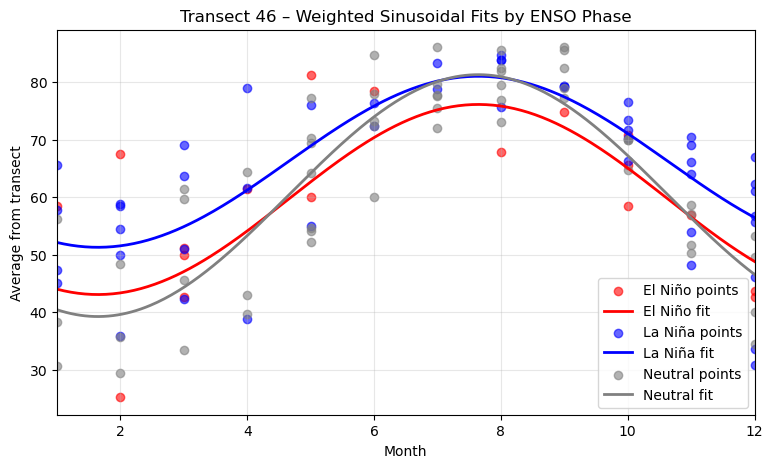

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# --- Define sinusoidal function ---
def sine_func(x, A, phi, C):
    """A * sin(2πx/12 - phi) + C"""
    return A * np.sin(2 * np.pi * (x - phi) / 12) + C


# --- Copy data and initialize storage ---
df = monthly_df_ONI_compiled.copy()
ONI_trends_storage = {'transect': [], 'data': []}
last_transect_number = 246

lst = list(range(1, last_transect_number - 4))  # goes from 1 to 244
for i in lst:
    transects = generate_transect_list(start_transect=i, end_transect=i + 4)
    df['Average_from_transect'] = df[transects].mean(axis=1)
    df = df.dropna(subset=['Average_from_transect', 'ENSO_phase', 'month'])

    # --- STEP 1: Find shared phase using ALL data ---
    x_all = df['month'].values
    y_all = df['Average_from_transect'].values

    popt_global, _ = curve_fit(
        sine_func,
        x_all,
        y_all,
        p0=[(y_all.max() - y_all.min()) / 2, 0, np.mean(y_all)],
        maxfev=2000
    )
    A_all, phi_global, C_all = popt_global

    # --- STEP 2: Fit each ENSO phase individually (A and C) ---
    results = []
    fit_results = {}  # store for plotting

    for phase in ['El Niño', 'La Niña', 'Neutral']:
        subset = df[df['ENSO_phase'] == phase]
        x = subset['month'].values
        y = subset['Average_from_transect'].values

        if len(x) < 6:
            continue

        # --- Apply weighting for El Niño and La Niña using |ANOM| ---
        if phase in ['El Niño', 'La Niña']:
            weights = subset['ANOM'].abs().values
            sigma = 1 / (weights + 1e-6)  # smaller sigma = higher weight
        else:
            sigma = None  # Neutral phase unweighted

        try:
            popt, _ = curve_fit(
                lambda m, A, C: sine_func(m, A, phi_global, C),
                x, y,
                p0=[(np.nanmax(y) - np.nanmin(y)) / 2, np.nanmean(y)],
                sigma=sigma,
                absolute_sigma=True,
                maxfev=2000
            )
            A, C = popt
        except RuntimeError:
            continue

        # --- Generate smooth curve ---
        x_smooth = np.linspace(1, 12, 300)
        y_smooth = sine_func(x_smooth, A, phi_global, C)

        # --- Extract peak/trough info ---
        peak_idx = np.argmax(y_smooth)
        trough_idx = np.argmin(y_smooth)
        peak_month = x_smooth[peak_idx]
        trough_month = x_smooth[trough_idx]
        peak_val = y_smooth[peak_idx]
        trough_val = y_smooth[trough_idx]

        # --- Store results ---
        results.append({
            'ENSO_phase': phase,
            'Mean_C': C,
            'Peak_value': peak_val,
            'Trough_value': trough_val,
            'difference': peak_val - trough_val,
            'transect': i + 2
        })

        fit_results[phase] = (x, y, x_smooth, y_smooth)

    # --- Convert to DataFrame ---
    df_curve_summary = pd.DataFrame(results)
    ONI_trends_storage['transect'].append(i + 2)
    ONI_trends_storage['data'].append(df_curve_summary)

    # --- Plot example (choose one transect to plot, e.g., i == 100) ---
    if i == 44:  # change number to whichever transect you want to visualize
        plt.figure(figsize=(9, 5))
        colors = {'El Niño': 'red', 'La Niña': 'blue', 'Neutral': 'gray'}

        for phase, (x, y, x_smooth, y_smooth) in fit_results.items():
            plt.scatter(x, y, color=colors[phase], label=f'{phase} points', alpha=0.6)
            plt.plot(x_smooth, y_smooth, color=colors[phase], lw=2, label=f'{phase} fit')

        plt.title(f'Transect {i+2} – Weighted Sinusoidal Fits by ENSO Phase')
        plt.xlabel('Month')
        plt.ylabel('Average from transect')
        plt.xlim(1, 12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


In [158]:
ONI_trends_storage['data']
merged_raw = merged_raw.set_index("id")
max_difference = [] # nino max width  - la nina max width: positive  = nino larger width
min_difference = [] #nino min width - la nina min width: psotiive = nino large width
merged_raw['min_nino-nina_difference_norm']= np.nan
merged_raw['max_nino-nina_difference_norm']= np.nan
merged_raw['min_nino-nina_difference_raw']= np.nan
merged_raw['max_nino-nina_difference_raw']= np.nan
for i in range(len(ONI_trends_storage['data'])):
    transect = ONI_trends_storage['transect'][i]
    
    mean = merged_raw['baseline_average'][f"oahu0012_{transect:04d}"]
    std = merged_raw['baseline_std'][f"oahu0012_{transect:04d}"]

    nino_max_norm = (ONI_trends_storage['data'][i].set_index('ENSO_phase')['Peak_value']['El Niño'] - mean) / std
    nina_max_norm = (ONI_trends_storage['data'][i].set_index('ENSO_phase')['Peak_value']['La Niña'] - mean) / std
    max_width_difference = ONI_trends_storage['data'][i].set_index('ENSO_phase')['Peak_value']['El Niño'] - ONI_trends_storage['data'][i].set_index('ENSO_phase')['Peak_value']['La Niña']
    max_diff = abs(nino_max_norm) - abs(nina_max_norm)
    max_difference.append(max_diff)

    nino_min_norm = (ONI_trends_storage['data'][i].set_index('ENSO_phase')['Trough_value']['El Niño'] - mean) / std
    nina_min_norm = (ONI_trends_storage['data'][i].set_index('ENSO_phase')['Trough_value']['La Niña'] - mean) / std
    min_width_difference = ONI_trends_storage['data'][i].set_index('ENSO_phase')['Trough_value']['El Niño'] - ONI_trends_storage['data'][i].set_index('ENSO_phase')['Trough_value']['La Niña']
    min_diff = abs(nino_min_norm) - abs(nina_min_norm)
    min_difference.append(min_diff)
    merged_raw['min_nino-nina_difference_norm'][f"oahu0012_{transect:04d}"] = min_diff
    merged_raw['max_nino-nina_difference_norm'][f"oahu0012_{transect:04d}"] = max_diff

    merged_raw['min_nino-nina_difference_raw'][f"oahu0012_{transect:04d}"] = min_width_difference
    merged_raw['max_nino-nina_difference_raw'][f"oahu0012_{transect:04d}"] = max_width_difference

merged_raw = merged_raw.reset_index()

KeyError: "None of ['id'] are in the columns"

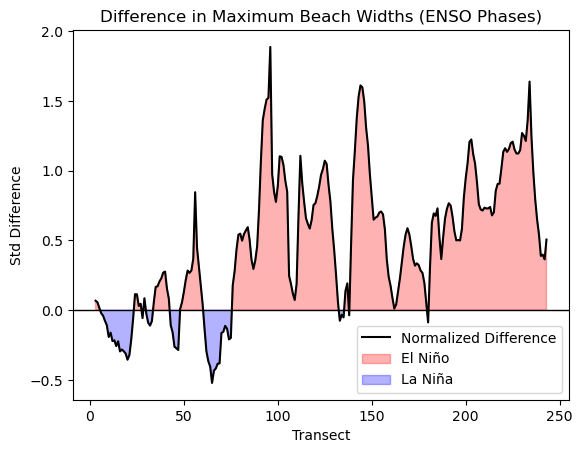

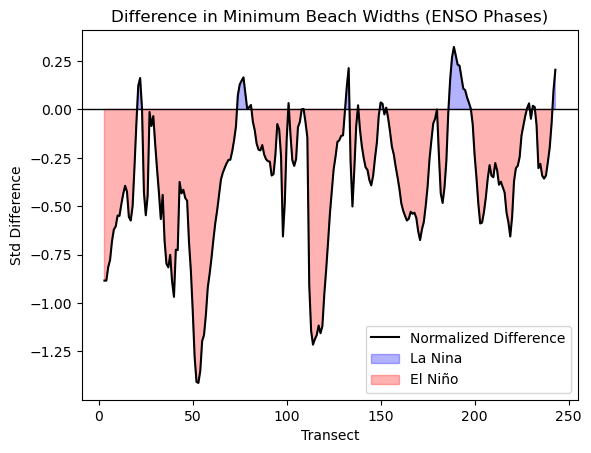

In [156]:
x = np.array(ONI_trends_storage['transect'])
y = np.array(max_difference)

plt.plot(x, y, color='black', label='Normalized Difference')

# Fill between the curve and y=0 (red for >0, blue for <0)
plt.fill_between(
    x, 0, y,
    where=(y > 0),
    color='red',
    alpha=0.3,
    interpolate=True,
    label='El Niño'
)

plt.fill_between(
    x, 0, y,
    where=(y < 0),
    color='blue',
    alpha=0.3,
    interpolate=True,
    label='La Niña'
)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Transect')
plt.ylabel('Std Difference')
plt.title('Difference in Maximum Beach Widths (ENSO Phases)')
plt.legend()
plt.show()


x = np.array(ONI_trends_storage['transect'])
y = np.array(min_difference) * -1

plt.plot(x, y, color='black', label='Normalized Difference')

# Fill between the curve and y=0 (red for >0, blue for <0)
plt.fill_between(
    x, 0, y,
    where=(y > 0),
    color='blue',
    alpha=0.3,
    interpolate=True,
    label='La Nina'
)

plt.fill_between(
    x, 0, y,
    where=(y < 0),
    color='red',
    alpha=0.3,
    interpolate=True,
    label='El Niño'
)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Transect')
plt.ylabel('Std Difference')
plt.legend()
plt.title('Difference in Minimum Beach Widths (ENSO Phases)')
plt.show()


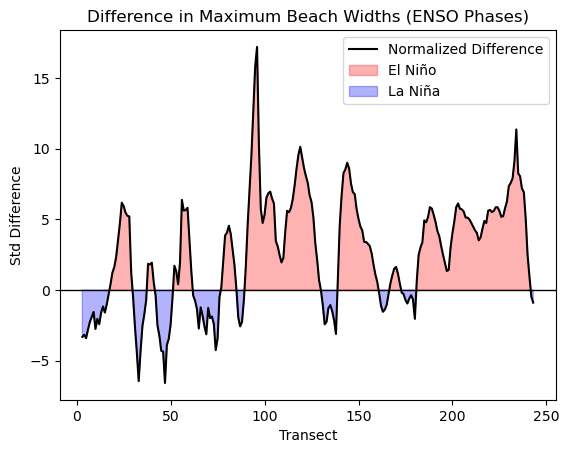

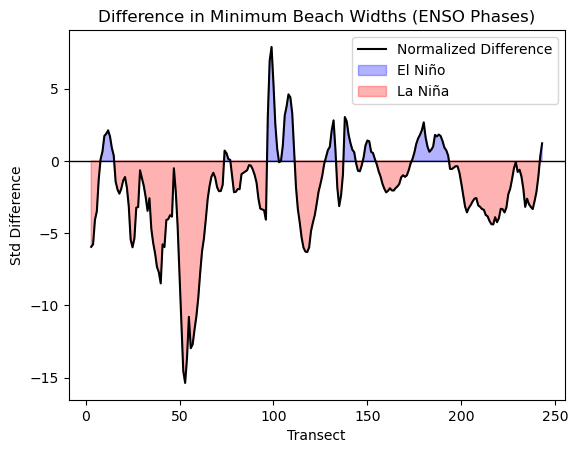

In [148]:
x = np.array(merged_raw['transect'])
y = np.array(merged_raw['max_nino-nina_difference_raw'])

plt.plot(x, y, color='black', label='Normalized Difference')

# Fill between the curve and y=0 (red for >0, blue for <0)
plt.fill_between(
    x, 0, y,
    where=(y > 0),
    color='red',
    alpha=0.3,
    interpolate=True,
    label='El Niño'
)

plt.fill_between(
    x, 0, y,
    where=(y < 0),
    color='blue',
    alpha=0.3,
    interpolate=True,
    label='La Niña'
)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Transect')
plt.ylabel('Std Difference')
plt.title('Difference in Maximum Beach Widths (ENSO Phases)')
plt.legend()
plt.show()


x = np.array(merged_raw['transect'])
y = np.array(merged_raw['min_nino-nina_difference_raw'])

plt.plot(x, y, color='black', label='Normalized Difference')

# Fill between the curve and y=0 (red for >0, blue for <0)
plt.fill_between(
    x, 0, y,
    where=(y > 0),
    color='blue',
    alpha=0.3,
    interpolate=True,
    label='El Niño'
)

plt.fill_between(
    x, 0, y,
    where=(y < 0),
    color='red',
    alpha=0.3,
    interpolate=True,
    label='La Niña'
)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Transect')
plt.ylabel('Std Difference')
plt.legend()
plt.title('Difference in Minimum Beach Widths (ENSO Phases)')
plt.show()


In [125]:
merged = merged_raw.copy()
merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_ENSO_nromalized.shp"
merged.to_file(output_path)

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\3985518434.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_std' to 'baseline_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_max' to 'mean_month'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_min' to 'mean_mon_1'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_max_std' to 'mean_max_s'
  ogr_

#### create shapefiles to view data

In [10]:
import geopandas as gpd
from shapely.ops import substring
import pandas as pd

merged = merged_raw.copy()

# Define the cutting functions
def cut_line_starting_at_0(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, 0, distance)

def cut_line_starting_at_end_length(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, length - distance, length)


# ===================== 1. BETWEEN MEAN MIN AND MEAN MAX =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['mean_monthly_max']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['mean_monthly_max'] - row['mean_monthly_min'])
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_min-max.shp"
merged.to_file(output_path)


# ===================== 2. BETWEEN MEAN MIN AND MIN STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['mean_monthly_min']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(row['geometry'], row['mean_min_std']),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_min-std.shp"
merged.to_file(output_path)


# ===================== 3. BETWEEN MEAN MAX AND MAX STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['mean_monthly_max'] + row['mean_max_std'])
    ),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(row['geometry'], row['mean_max_std']),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_between_max-std.shp"
merged.to_file(output_path)


# ===================== 4. BETWEEN MAX AND MAX STD =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['max']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['max'] - (row['mean_monthly_max'] + row['mean_max_std']))
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_MAX.shp"
merged.to_file(output_path)


# ===================== 5. BETWEEN MIN AND (MIN - STD) =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['mean_monthly_min'] - row['mean_min_std'])
    ),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['mean_monthly_min'] - row['mean_min_std']) - row['min']
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_cut_by_monthly_MIN.shp"
merged.to_file(output_path)


# ===================== 5. VEGETTATION BUFFER =====================
merged = merged_raw.copy()

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(
        row['geometry'],
        (row['min'])
    ),
    axis=1
)


merged = merged.dropna(subset=['geometry'])
output_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\transect_cuts\NS_transects_veg.shp"
merged.to_file(output_path)


print(f"✅ All shapefiles saved successfully.")


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\1641297864.py:48: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_max' to 'mean_month'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_min' to 'mean_mon_1'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_max_std' to 'mean_max_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_min_std' to 'mean_min_s'
  ogr

✅ All shapefiles saved successfully.


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_12020\1641297864.py:105: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_max' to 'mean_month'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_monthly_min' to 'mean_mon_1'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_max_std' to 'mean_max_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_min_std' to 'mean_min_s'
  og

# Start looking at ONI trends

In [11]:
import pandas as pd
import numpy as np

# Ensure datetime
df_oni['dates'] = pd.to_datetime(df_oni['dates'])

# Define thresholds
EL_NINO = 0.5
LA_NINA = -0.5
WINDOW = 5  # 5 consecutive 3-month periods

# Initialize phase column
df_oni['ENSO_phase'] = 'Neutral'

# Boolean masks
is_el_nino = df_oni['oni'] >= EL_NINO
is_la_nina = df_oni['oni'] <= LA_NINA

# Convert to numpy arrays for speed
el = is_el_nino.values
la = is_la_nina.values

# Start with neutral everywhere
phase = np.array(['Neutral'] * len(df_oni), dtype=object)

# --- Mark El Niño runs ---
count = 0
for i in range(len(el)):
    if el[i]:
        count += 1
    else:
        count = 0
    if count >= WINDOW:
        phase[i - WINDOW + 1:i + 1] = 'El Niño'

# --- Mark La Niña runs ---
count = 0
for i in range(len(la)):
    if la[i]:
        count += 1
    else:
        count = 0
    if count >= WINDOW:
        phase[i - WINDOW + 1:i + 1] = 'La Niña'

# Assign back to DataFrame
df_oni['ENSO_phase'] = phase

# Optional: keep key columns only
df_oni_simple = df_oni[['dates', 'oni', 'ENSO_phase']]
print(df_oni_simple.head(20))


KeyError: 'dates'

In [ ]:
df_oni_simple.to_csv('testing33.csv')

# NOW we will average across multiple transects that show similar wave characteristics

# Plot raw data?

In [ ]:
transects =  generate_transect_list(start_transect = 48, end_transect = 52)
df=  merged_planet_coast 

In [ ]:
df['Average_from_transect'] = df[transects].mean(axis=1)
# Ensure datetime types
df_oni['dates'] = pd.to_datetime(df_oni['dates'])
df.index = pd.to_datetime(df.index)

# Create year-month keys
df['year_month'] = df.index.to_period('M')
df_oni['year_month'] = df_oni['dates'].dt.to_period('M')

# Merge ONI monthly values into df_planet
merged_df = pd.merge(
    df.reset_index(),  # bring index as 'dates'
    df_oni[['year_month', 'oni']],
    on='year_month',
    how='left'
)

# Drop helper column and restore datetime index
merged_df = merged_df.drop(columns='year_month').set_index('dates')

# ---------------------------------------------------
# Add color and size columns based on ONI
# ---------------------------------------------------
def oni_color(oni):
    if oni > 0.5:
        return 'red'     # El Niño
    elif oni < -0.5:
        return 'blue'    # La Niña
    else:
        return 'gray'    # Neutral

merged_df['color'] = merged_df['oni'].apply(oni_color)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
plt.scatter(
    merged_df.index,
    merged_df['Average_from_transect'],   # or any column you want to plot
    s=20, #merged_df['size'],
    c=merged_df['color'],
    alpha=0.8,
    edgecolor='k'
)

plt.xlabel('Date')
plt.ylabel('Width')
plt.title('Transect Widths Colored by ONI Phase')
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
# --- Step 1. Resample to monthly means ---
merged_df.index = pd.to_datetime(merged_df.index)
monthly_df = merged_df.resample('ME').mean(numeric_only=True)

monthly_df['month'] = monthly_df.index.month

# --- Step 2. Compute mean and std per calendar month ---
seasonal = monthly_df.groupby('month')['Average_from_transect'].agg(['mean', 'std'])

x = np.arange(1, 13)
y = seasonal['mean'].values
y_std = seasonal['std'].values

# --- Step 3. Define and fit sinusoidal model ---
def sine_func(x, A, phi, C):
    """A * sin(2πx/12 - phi) + C"""
    return A * np.sin(2 * np.pi * (x - phi) / 12) + C

# Initial guess: amplitude, phase shift, offset
popt, _ = curve_fit(sine_func, x, y, p0=[(y.max() - y.min()) / 2, 0, np.mean(y)])
A, phi, C = popt

# --- Step 4. Generate smooth curve ---
x_smooth = np.linspace(1, 12, 300)
y_smooth = sine_func(x_smooth, *popt)

# --- Step 5. Plot ---
plt.figure(figsize=(10, 6))

# Shaded ±1σ band
plt.fill_between(
    x,
    y - y_std,
    y + y_std,
    color='gray',
    alpha=0.5,
    label='±1σ Variability'
)

# Observed monthly means
plt.scatter(
    x,
    y,
    color='darkorange',
    s=90,
    edgecolor='k',
    zorder=3,
    label='Monthly Mean'
)

# Sinusoidal fit
plt.plot(
    x_smooth,
    y_smooth,
    color='black',
    linewidth=2.5,
    label='Sinusoidal Fit'
)

# --- Step 6. Format ---
plt.xticks(
    ticks=np.arange(1, 13),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.xlabel('Month')
plt.ylabel('Transect Width')
plt.title('Seasonal Cycle of Transect Width (Sinusoidal Fit ± 1σ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Print fit parameters ---
print(f"Amplitude (A): {A:.2f}")
print(f"Phase shift (φ): {phi:.2f} months")
print(f"Mean level (C): {C:.2f}")



In [ ]:
# --- Step 2. Classify ONI phase ---
def oni_phase(val):
    if val > 0.5:
        return 'El Niño'
    elif val < -0.5:
        return 'La Niña'
    else:
        return 'Neutral'

monthly_df['phase'] = monthly_df['oni'].apply(oni_phase)

# --- Step 3. Sinusoidal model ---
def sine_func(x, A, phi, C):
    return A * np.sin(2 * np.pi * (x - phi) / 12) + C

# --- Step 4. Fit and plot each ONI phase ---
colors = {'El Niño': 'red', 'Neutral': 'gray', 'La Niña': 'blue'}
plt.figure(figsize=(10, 6))

for phase, group in monthly_df.groupby('phase'):
    # Compute average seasonal pattern for this phase
    seasonal = group.groupby('month')['Average_from_transect'].mean().dropna()
    if len(seasonal) < 4:  # not enough months to fit a sine wave
        continue
    
    x = seasonal.index.values
    y = seasonal.values

    # Fit sinusoidal curve
    try:
        popt, _ = curve_fit(
            sine_func,
            x,
            y,
            p0=[(y.max() - y.min()) / 2, 0, np.mean(y)]
        )
        x_smooth = np.linspace(1, 12, 300)
        y_smooth = sine_func(x_smooth, *popt)

        # Plot the sinusoidal fit
        plt.plot(
            x_smooth,
            y_smooth,
            color=colors[phase],
            linewidth=2.5,
            label=f"{phase} (fit)"
        )

        # Plot mean points
        plt.scatter(
            x,
            y,
            color=colors[phase],
            edgecolor='k',
            s=90,
            zorder=3,
            label=f"{phase} mean"
        )
    except RuntimeError:
        print(f"Could not fit sine curve for {phase}")

# --- Step 5. Format plot ---
plt.xticks(
    ticks=np.arange(1, 13),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.xlabel('Month')
plt.ylabel('Transect Width')
plt.title('Seasonal Transect Widths by ONI Phase (Sinusoidal Fits)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure month and phase exist ---
if 'month' not in monthly_df.columns:
    monthly_df['month'] = pd.to_datetime(monthly_df['dates']).dt.month

def oni_phase(val):
    if val > 0.5:   return 'El Niño'
    if val < -0.5:  return 'La Niña'
    return 'Neutral'

monthly_df['phase'] = monthly_df['oni'].apply(oni_phase)

# --- Colors ---
colors = {'El Niño': 'red', 'La Niña': 'blue', 'Neutral': 'gray'}

# --- Helper to get mean/std per month for a phase ---
def monthly_stats(df_phase):
    # mean & std per calendar month
    m = df_phase.groupby('month')['Average_from_transect'].mean()
    s = df_phase.groupby('month')['Average_from_transect'].std()
    # reindex to full 1..12 so fill_between has continuous x
    idx = pd.Index(np.arange(1,13), name='month')
    return m.reindex(idx), s.reindex(idx)

plt.figure(figsize=(10, 6))

for phase, dfp in monthly_df.groupby('phase'):
    mean_m, std_m = monthly_stats(dfp)
    x = np.arange(1, 13)
    y = mean_m.values
    ylo = (mean_m - std_m).values
    yhi = (mean_m + std_m).values

    # Plot mean line
    plt.plot(x, y, color=colors[phase], linewidth=2.5, label=f'{phase} mean')

    # Shaded ±1σ band
    plt.fill_between(x, ylo, yhi, color=colors[phase], alpha=0.25, label=f'{phase} ±1σ')

# --- Format plot ---
plt.xticks(
    ticks=np.arange(1, 13),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.xlabel('Month')
plt.ylabel('Transect Width')
plt.title('Seasonal Transect Widths by ONI Phase (Mean ± 1σ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ---------- 1) Prep your data ----------
dfp = df_stats.copy().sort_values('transect')
x = pd.to_numeric(dfp['transect'], errors='coerce').to_numpy()
y = pd.to_numeric(dfp['max_date'], errors='coerce').to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

# scale x to [0, 1] for stable Fourier features
t = (x - x.min()) / (x.max() - x.min())

# ---------- 2) Fourier design + model selection ----------
def fourier_design(t, K: int):
    """Intercept + [cos(2πkt), sin(2πkt)] for k=1..K."""
    t = np.asarray(t)
    cols = [np.ones_like(t)]
    for k in range(1, K + 1):
        cols.append(np.cos(2*np.pi*k*t))
        cols.append(np.sin(2*np.pi*k*t))
    return np.column_stack(cols)

def fit_best_harmonics(t, y, Kmax=25, criterion="AICc"):
    """
    Pick the number of harmonics using AICc (default) or BIC.
    Returns dict with best K, coefficients, and score.
    """
    n = len(y)
    # ensure we don't exceed degrees of freedom: p = 1 + 2K < n - 1
    Kmax = min(Kmax, max(1, (n - 2) // 2))
    best = {"K": 1, "beta": None, "score": np.inf}

    for K in range(1, Kmax + 1):
        X = fourier_design(t, K)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        sse = float(np.sum(resid**2))
        p = X.shape[1]
        # model selection score
        if criterion.lower() == "bic":
            score = n * np.log(sse / n) + p * np.log(n)
        else:  # AICc (stronger penalty than AIC for small samples)
            aic = n * np.log(sse / n) + 2 * p
            score = aic + (2 * p * (p + 1)) / max(1, n - p - 1)
        if score < best["score"]:
            best = {"K": K, "beta": beta, "score": score}
    return best

best = fit_best_harmonics(t, y, Kmax=100, criterion="AICc")
K, beta = best["K"], best["beta"]

# ---------- 3) Evaluate a smooth curve over a dense grid ----------
t_grid = np.linspace(t.min(), t.max(), 1000)
X_grid = fourier_design(t_grid, K)
y_smooth = X_grid @ beta
x_grid = x.min() + t_grid * (x.max() - x.min())

# ---------- 4) Plot ----------
plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=16, alpha=0.45, label='max_date (raw)')
plt.plot(x_grid, y_smooth, linewidth=2.5, label=f'Sinusoidal fit (Fourier, K={K})')
plt.xlabel('Transect')
plt.ylabel('max_date')
plt.title('max_date – adaptive sinusoidal curve (sum of sinusoids)')
plt.xlim(0, 150)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Prep data (from df_stats) ----------
dfp = (
    df_stats.copy()
    .sort_values('transect')
    .assign(
        transect=lambda d: pd.to_numeric(d['transect'], errors='coerce'),
        max_date=lambda d: pd.to_numeric(d['max_date'], errors='coerce')
    )
).dropna(subset=['transect','max_date'])

x_raw = dfp['transect'].to_numpy()
y_raw = dfp['max_date'].to_numpy()

# scale x to [0, 1] for stable Fourier features
t = (x_raw - x_raw.min()) / (x_raw.max() - x_raw.min())

# ---------- 2) Fourier fit (same as your routine) ----------
def fourier_design(t, K: int):
    t = np.asarray(t)
    cols = [np.ones_like(t)]
    for k in range(1, K + 1):
        cols.append(np.cos(2*np.pi*k*t))
        cols.append(np.sin(2*np.pi*k*t))
    return np.column_stack(cols)

def fit_best_harmonics(t, y, Kmax=25, criterion="AICc"):
    n = len(y)
    Kmax = min(Kmax, max(1, (n - 2) // 2))
    best = {"K": 1, "beta": None, "score": np.inf}
    for K in range(1, Kmax + 1):
        X = fourier_design(t, K)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        sse = float(np.sum(resid**2))
        p = X.shape[1]
        if criterion.lower() == "bic":
            score = n * np.log(sse / n) + p * np.log(n)
        else:
            aic = n * np.log(sse / n) + 2 * p
            score = aic + (2 * p * (p + 1)) / max(1, n - p - 1)
        if score < best["score"]:
            best = {"K": K, "beta": beta, "score": score}
    return best

best = fit_best_harmonics(t, y_raw, Kmax=25, criterion="AICc")
K, beta = best["K"], best["beta"]

# dense grid to draw a smooth curve across the whole transect axis
t_grid = np.linspace(t.min(), t.max(), 2000)
X_grid = fourier_design(t_grid, K)
y_smooth = X_grid @ beta
x_grid = x_raw.min() + t_grid * (x_raw.max() - x_raw.min())

# ---------- 3) Plot raw points ----------
plt.figure(figsize=(10,5))
plt.scatter(x_raw, y_raw, s=16, alpha=0.45, label='Month of Maximum')

# ---------- 4) Color the entire fitted curve by month ranges ----------
# Bins you specified:
# 3–4: dark blue (late winter)
# 5–6: light green (early summer)
# 7–8: dark red (peak of summer)
# 9–10: orange (early winter)
segments = [
    ((y_smooth >= 3)  & (y_smooth < 5),  'navy',       'Late winter (3–4)'),
    ((y_smooth >= 5)  & (y_smooth < 7),  'lightgreen', 'Early summer (5–6)'),
    ((y_smooth >= 7)  & (y_smooth < 9),  'darkred',    'Peak of summer (7–8)'),
    ((y_smooth >= 9)  & (y_smooth <=10), 'orange',     'Early winter (9–10)'),
]

# helper to avoid duplicate legend entries when a phase appears in multiple chunks
seen = set()
for mask, color, label in segments:
    y_plot = np.where(mask, y_smooth, np.nan)  # breaks the line where mask is False
    lbl = label if label not in seen else None
    plt.plot(x_grid, y_plot, color=color, linewidth=2.5, label=lbl)
    seen.add(label)

# ---------- 5) Finish plot ----------
plt.xlabel('Transect')
plt.ylabel('Month of maximum width')
plt.title(f'Spatial and Temporal Trends of the Maximum Beach Width (Fourier fit, K={K})')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
